# Unidad 3 · CLSP: lot-sizing multiproducto con capacidad

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/3_Planificacion/Planificiacion/` — 12 semanas, 6 SKU, 4 recursos
**Solver:** Gurobi

---

## Qué se decide aquí

En el cuaderno anterior cada SKU se resolvía por separado y no había
capacidad. Los seis problemas eran independientes y Wagner-Whitin los cerraba
en milisegundos. Aquí se agrega **una sola cosa** —que las máquinas son
finitas y compartidas— y el problema cambia de naturaleza.

La planta tiene cuatro recursos:

* **PREP**, las marmitas donde se cocina el preparado a granel;
* **L1**, la línea de envasado del formato 480 g;
* **L2**, la línea de los formatos 820 g y 3000 g;
* **AUT**, el autoclave de esterilización, por donde pasa **todo**.

Las horas disponibles no son constantes: hay mantenciones programadas y un
feriado que recortan semanas concretas. Y la demanda tampoco: la semana 3 es
la de Fiestas Patrias y concentra un 40 % más que una semana normal.

## Lo que se rompe al agregar capacidad

1. **Se cae la propiedad de Wagner-Whitin.** Sin capacidad, en el óptimo
   nunca se produce en una semana que arrastra inventario (`I_{t-1}·x_t = 0`).
   Con capacidad eso es falso: si la semana 3 no cabe en horas, hay que
   *adelantar* producción, y entonces el inventario de entrada y la
   producción son positivos a la vez. Sin esa propiedad, la recursión de la
   programación dinámica no tiene de dónde agarrarse.
2. **Los SKU dejan de ser independientes.** Comparten AUT y comparten línea.
   Ya no hay seis problemas de 12 semanas: hay uno con 72 binarias acopladas.
3. **El CLSP es NP-difícil** incluso con un solo recurso. No hay algoritmo
   polinómico conocido. Queda el MIP, y con el MIP vuelve a importar el
   **big-M**.

## El big-M en presencia de capacidad

El cuaderno 01 usó `M = demanda restante desde t`. Aquí aparece una **segunda
cota**, independiente y muchas veces más fuerte: lo que *físicamente cabe* en
el recurso más restrictivo de esa semana,

$$M_{it} = \min\Big(\underbrace{\textstyle\sum_{u \ge t} d_{iu}}_{\text{cota económica}},\;
  \underbrace{\min_{r}\frac{\text{horas}_{rt} - s_{ir}}{a_{ir}}}_{\text{cota física}}\Big)$$

Las dos son válidas; la que sirve es el mínimo. Y la segunda depende de `t`,
así que el big-M **no es un número: es una matriz** (i, t).

## Cifras de referencia

| resultado | valor |
|---|---|
| CLSP básico, objetivo | **16 457 114 CLP** |
| preparaciones | **34** |
| gap de la relajación lineal en la raíz, big-M ajustado | **54,2 %** |
| gap en la raíz, big-M = 10⁶ | **99,2 %** |
| recurso cuello de botella | **AUT** (92 % de sus horas regulares) |
| pares (i, t) que violan la propiedad de Wagner-Whitin | **7** |

**Sobre el objetivo.** El costo variable de producción (13 400 CLP por caja
de DUR-480, etc.) está **excluido**. No hay pérdida de venta ni rutas
alternativas, así que ese término es prácticamente una constante: se lleva
el 98 % del gasto total y no depende de las decisiones que el modelo toma.
Dejarlo dentro esconde el intercambio que sí importa. Se reporta aparte.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

dem = pd.read_csv(datos("3_Planificacion", "itata_demanda_plan.csv"))
par = pd.read_csv(datos("3_Planificacion", "itata_parametros_sku.csv"))
cap = pd.read_csv(datos("3_Planificacion", "itata_capacidad.csv"))
tas = pd.read_csv(datos("3_Planificacion", "itata_tasas.csv"))
rec = pd.read_csv(datos("3_Planificacion", "itata_recursos.csv"))
ini = pd.read_csv(datos("3_Planificacion", "itata_inventario_inicial.csv"))

SKUS = list(par.sku)
T = sorted(dem.t.unique().tolist())
REC = sorted(cap.recurso.unique().tolist())

print(f"{len(SKUS)} SKU · {len(T)} semanas · {len(REC)} recursos")
print(rec.to_string(index=False))

6 SKU · 12 semanas · 4 recursos
recurso                              descripcion  horas_regulares_sem  horas_extra_max_sem  costo_hora_extra_clp
   PREP           Marmitas de preparado a granel                 46.0                  8.0                138000
     L1                  Linea de envasado 480 g                 45.0                 10.0                121000
     L2         Linea de envasado 820 g y 3000 g                 26.0                  8.0                116000
    AUT Autoclave de esterilizacion (compartido)                 48.0                  6.0                204000


## 1. Los datos, en las estructuras que el modelo va a usar

Tres cosas que conviene mirar antes de escribir una sola restricción.

**El consumo es por recurso y por caja.** Cada SKU pasa por PREP (cocción del
granel), por **su** línea de envasado (L1 o L2, no ambas) y por AUT. El
archivo `itata_tasas.csv` trae las tres tasas en horas por caja.

**El tiempo de setup se consume en la línea**, no en todos los recursos. Es
el CIP de la llenadora: cambiar de producto obliga a limpiar esa máquina. Por
eso `tiempo_setup` está indexado en (SKU, su línea).

**La capacidad varía por semana.** `itata_capacidad.csv` no repite las horas
nominales de `itata_recursos.csv`: les descuenta las mantenciones. Ignorar esa
columna es el error más caro del cuaderno, porque produce un plan que no cabe
justo en las semanas en que la planta está más apretada.

Un detalle de pandas que muerde: la columna del archivo de inventario se
llama `item`, y `fila.item` en pandas **no** devuelve esa columna sino el
método `Series.item`. Hay que escribir `df["item"]`. El síntoma es un
inventario inicial silenciosamente igual a cero.

In [2]:
demanda = {(r.sku, int(r.t)): float(r.demanda_cajas) for _, r in dem.iterrows()}
p = par.set_index("sku")
costo_setup = {i: float(p.loc[i, "costo_setup_clp"]) for i in SKUS}
costo_almacen = {i: float(p.loc[i, "costo_almacen_clp_caja_sem"]) for i in SKUS}
costo_prod = {i: float(p.loc[i, "costo_unitario_clp_caja"]) for i in SKUS}
stock_seg = {i: float(p.loc[i, "stock_seguridad_cajas"]) for i in SKUS}

# OJO: df["item"], no df.item  (ver la nota de arriba)
_ini = dict(zip(ini["item"], ini.inventario_inicial.astype(float)))
inv_ini = {i: _ini.get(i, 0.0) for i in SKUS}

linea = dict(zip(tas.sku, tas.linea))

# consumo[(sku, recurso)] = horas por caja
consumo = {}
for _, r in tas.iterrows():
    consumo[(r.sku, "PREP")] = float(r.h_por_caja_PREP)
    consumo[(r.sku, "AUT")] = float(r.h_por_caja_AUT)
    consumo[(r.sku, r.linea)] = float(r.h_por_caja_linea)

# el setup se paga en HORAS sobre la linea de envasado del SKU
tiempo_setup = {(r.sku, linea[r.sku]): float(r.tiempo_setup_h) for _, r in par.iterrows()}

capacidad = {(r.recurso, int(r.t)): float(r.horas_disponibles) for _, r in cap.iterrows()}
extra_max = {(r.recurso, int(r.t)): float(r.horas_extra_max) for _, r in cap.iterrows()}

print("Inventario inicial (cajas):", {i: inv_ini[i] for i in SKUS})
print("\nSemanas con capacidad reducida:\n")
print(cap[cap.observacion.notna()][["t", "recurso", "horas_disponibles",
                                    "observacion"]].to_string(index=False))

Inventario inicial (cajas): {'DUR-480': 260.0, 'DUR-820': 38.0, 'TOM-480': 860.0, 'TOM-3000': 131.0, 'POR-480': 346.0, 'POR-3000': 41.0}

Semanas con capacidad reducida:

 t recurso  horas_disponibles                            observacion
 2    PREP               41.0                   revision de marmitas
12    PREP               38.0                                feriado
 7      L1               39.0      cambio de cabezal de la llenadora
12      L1               37.0                                feriado
12      L2               18.0                                feriado
 6     AUT               40.0    mantencion programada del autoclave
10     AUT               44.0 certificacion de valvulas de seguridad
12     AUT               40.0                                feriado


## 2. ¿Cabe la demanda en la planta?

Antes de optimizar hay que contestar una pregunta que la optimización no
contesta bien: **¿dónde está el cuello de botella y en qué semanas aprieta?**

La carga de un recurso `r` en la semana `t`, si se produjera exactamente la
demanda de esa semana, es

$$\text{carga}_{rt} = \sum_i a_{ir}\, d_{it} \;+\; \sum_i s_{ir}$$

El segundo término supone que se prepara todo (seis setups). Es una cota
pesimista, pero es la relevante: la semana apretada es justo aquella en que
no se puede dejar de preparar nada.

In [3]:
filas = []
for t in T:
    fila = {"t": t, "demanda_cajas": sum(demanda[(i, t)] for i in SKUS)}
    for r in REC:
        carga = sum(consumo.get((i, r), 0.0) * demanda[(i, t)] for i in SKUS)
        carga += sum(tiempo_setup.get((i, r), 0.0) for i in SKUS)
        fila[f"{r}_%"] = 100.0 * carga / capacidad[(r, t)]
    filas.append(fila)
util = pd.DataFrame(filas)
print("Utilizacion si la demanda de cada semana se produjera en esa semana (%):\n")
print(util.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

print("\nCarga del horizonte completo (solo produccion, sin setups):\n")
carga_horizonte = {}
for r in REC:
    carga = sum(consumo.get((i, r), 0.0) * demanda[(i, t)] for i in SKUS for t in T)
    reg = sum(capacidad[(r, t)] for t in T)
    ext = sum(extra_max[(r, t)] for t in T)
    carga_horizonte[r] = 100 * carga / reg
    print(f"  {r:5s}  carga {carga:7.1f} h | regular {reg:6.1f} h ({100*carga/reg:5.1f} %) "
          f"| con extra {reg+ext:6.1f} h ({100*carga/(reg+ext):5.1f} %)")

cuello_previo = max(REC, key=lambda r: carga_horizonte[r])
print(f"\nCuello de botella del horizonte: {cuello_previo}")

Utilizacion si la demanda de cada semana se produjera en esa semana (%):

 t  demanda_cajas  AUT_%  L1_%  L2_%  PREP_%
 1        6,775.0   93.8  91.3  73.8    86.0
 2        6,696.0   92.7  90.2  73.0    95.3
 3        8,465.0  117.0 112.5  88.1   107.2
 4        6,006.0   83.0  81.4  66.9    76.0
 5        6,442.0   88.9  86.8  70.5    81.5
 6        6,355.0  105.2  85.6  69.7    80.3
 7        6,268.0   86.4  97.5  68.8    79.1
 8        6,185.0   85.2  83.4  68.0    78.0
 9        6,105.0   84.0  82.3  67.2    77.0
10        6,030.0   90.4  81.3  66.5    76.0
11        5,960.0   81.9  80.4  65.8    75.0
12        5,896.0   97.2  96.8  94.1    89.8

Carga del horizonte completo (solo produccion, sin setups):

  AUT    carga   510.9 h | regular  556.0 h ( 91.9 %) | con extra  628.0 h ( 81.4 %)
  L1     carga   437.7 h | regular  526.0 h ( 83.2 %) | con extra  646.0 h ( 67.8 %)
  L2     carga   171.3 h | regular  304.0 h ( 56.4 %) | con extra  400.0 h ( 42.8 %)
  PREP   carga   448.6 h

### La lectura

**AUT es el cuello de botella del horizonte.** Ocupa el 92 % de sus horas
regulares solo con la producción de la demanda, sin contar setups ni
desbalances. Es el único recurso por el que pasan los seis SKU: L1 y L2 se
reparten los productos; PREP y AUT los ven a todos.

**La semana 3 no cabe.** Tres de los cuatro recursos pasan del 100 %: AUT,
L1 y PREP. Es la semana de Fiestas Patrias y la demanda salta a 8 465 cajas
contra las ~6 200 de una semana normal. Esa demanda **no se puede producir en
la semana 3**: hay que adelantarla, y adelantarla cuesta inventario.

Ese solo hecho predice la forma del plan óptimo antes de resolverlo, y ya
destruye la propiedad de Wagner-Whitin: en las semanas 1 y 2 habrá producción
**y** inventario de arrastre al mismo tiempo, que es exactamente lo que sin
capacidad nunca conviene.

Nótese también la semana 6: AUT al 105 % por la mantención programada del
autoclave, con demanda perfectamente normal. El cuello de botella no siempre
lo crea la demanda; a veces lo crea el calendario de mantención.

## 3. El big-M ajustado por (i, t)

La restricción de enlace `x_it ≤ M_it · y_it` dice "no se produce sin
preparar". El valor de `M_it` no cambia el óptimo entero mientras sea válido
—es decir, mientras no recorte ninguna solución factible—, pero cambia
radicalmente el costo de encontrarlo.

Dos cotas válidas, por razones distintas:

* **Económica.** Nunca conviene producir en `t` más que la demanda que queda
  por atender de `t` en adelante, más las reservas que el plan deba dejar en
  bodega. Producir de más solo agrega inventario que nadie consume.
  *(Esta cota **deja de ser válida si se permite backlog**; se vuelve sobre
  ello en el cuaderno 03, y la función ya lleva el interruptor.)*
* **Física.** Aunque conviniera, no cabe: descontadas las horas de setup, el
  recurso más restrictivo de esa semana limita cuántas cajas se pueden
  correr. Esta cota es la que aporta la capacidad y no existía en el
  cuaderno 01.

El mínimo de las dos es válido y es el que se usa.

**Una decisión de diseño que hay que declarar.** Los cuadernos 02, 03 y 04
comparten esta función, y varias de las variantes del cuaderno 03 admiten
horas extra y obligan a dejar stock de seguridad. Para que la MISMA cota sea
válida en toda la familia, el término físico cuenta también las horas extra
disponibles y el término económico suma las reservas. Eso la vuelve más
floja que una cota hecha a medida de este modelo básico. La sección 6
cuantifica exactamente cuánto cuesta esa comodidad.

In [4]:
# el modelo debe cerrar el horizonte con al menos el stock de seguridad en
# bodega; si no, vacia la bodega en t = 12 y el plan no es implementable
inv_final_min = dict(stock_seg)


def big_M(i, t, con_backlog=False, con_extra=True, con_reserva=True):
    """Cota superior VALIDA y ajustada para la produccion de i en t."""
    if con_backlog:
        # con backlog, demanda de CUALQUIER periodo puede seguir pendiente
        resto = sum(demanda[(i, u)] for u in T) - inv_ini[i]
    else:
        resto = sum(demanda[(i, u)] for u in T if u >= t)
    resto = max(0.0, resto)
    if con_reserva:
        resto += stock_seg[i] + inv_final_min[i]

    fisico = float("inf")
    for r in REC:
        a = consumo.get((i, r), 0.0)
        if a <= 0:
            continue
        horas = capacidad.get((r, t), 0.0) - tiempo_setup.get((i, r), 0.0)
        if con_extra:
            horas += extra_max.get((r, t), 0.0)
        fisico = min(fisico, max(0.0, horas) / a)
    return float(min(resto, fisico))


filas = []
for i in SKUS:
    for t in (1, 3, 12):
        eco = sum(demanda[(i, u)] for u in T if u >= t) + stock_seg[i] + inv_final_min[i]
        fis = min((capacidad[(r, t)] + extra_max[(r, t)] - tiempo_setup.get((i, r), 0.0))
                  / consumo[(i, r)] for r in REC if consumo.get((i, r), 0.0) > 0)
        filas.append({"sku": i, "t": t, "cota_economica": eco, "cota_fisica": fis,
                      "M_it": big_M(i, t), "manda": "fisica" if fis < eco else "economica"})
cotas = pd.DataFrame(filas)
print(cotas.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))
print("\nEn los SKU de alto volumen manda la cota fisica; en los de bajo volumen")
print("y al final del horizonte, la economica. Quedarse con una sola de las dos")
print("deja la mitad del efecto sobre la mesa.")

     sku  t  cota_economica  cota_fisica  M_it     manda
 DUR-480  1          17,984        8,385 8,385    fisica
 DUR-480  3          15,513        8,385 8,385    fisica
 DUR-480 12           2,139        7,145 2,139 economica
 DUR-820  1           3,798        2,829 2,829    fisica
 DUR-820  3           3,266        2,829 2,829    fisica
 DUR-820 12             447        2,141   447 economica
 TOM-480  1          39,859        8,416 8,416    fisica
 TOM-480  3          32,810        8,416 8,416    fisica
 TOM-480 12           4,379        7,176 4,379 economica
TOM-3000  1           4,631        1,434 1,434    fisica
TOM-3000  3           3,825        1,434 1,434    fisica
TOM-3000 12             575        1,082   575 economica
 POR-480  1          12,658        8,385 8,385    fisica
 POR-480  3          10,294        8,385 8,385    fisica
 POR-480 12           1,301        7,145 1,301 economica
POR-3000  1           1,359        1,430 1,359 economica
POR-3000  3           1,110    

## 4. El modelo

$$
\begin{aligned}
\min \quad & \sum_{i,t} K_i\, y_{it} \;+\; \sum_{i,t} h_i\, I_{it} \\
\text{s.a.}\quad & I_{i,t-1} + x_{it} - d_{it} = I_{it} && \forall i, t \\
& x_{it} \le M_{it}\, y_{it} && \forall i, t \\
& \sum_i \big( a_{ir}\, x_{it} + s_{ir}\, y_{it} \big) \le \text{cap}_{rt} && \forall r, t \\
& x, I \ge 0,\quad y \in \{0,1\}
\end{aligned}
$$

Lo único nuevo respecto del cuaderno 01 es la tercera línea, y es la que
acopla los seis SKU. Nótese que el setup consume **horas** además de dinero:
`s_ir · y_it` está dentro de la restricción de capacidad. Un modelo que cobra
el setup solo en el objetivo produce planes que no caben en la planta.

In [5]:
def clsp(big_M_generico=None, big_M_a_medida=False, relajado=False,
         tiempo_limite=120.0, gap=1e-4, verbose=False):
    """CLSP basico multiproducto con capacidad. Devuelve (modelo, variables)."""
    m = gp.Model("CLSP")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    vt = GRB.CONTINUOUS if relajado else GRB.BINARY
    x = m.addVars(SKUS, T, lb=0.0, name="x")                     # cajas producidas
    y = m.addVars(SKUS, T, vtype=vt, lb=0.0, ub=1.0, name="y")   # hubo preparacion
    I = m.addVars(SKUS, T, lb=0.0, name="I")                     # inventario al cierre

    # --- balance de inventario
    for i in SKUS:
        for k, t in enumerate(T):
            previo = inv_ini[i] if k == 0 else I[i, T[k - 1]]
            m.addConstr(previo + x[i, t] - demanda[(i, t)] == I[i, t],
                        name=f"bal[{i},{t}]")

    # --- enlace produccion - preparacion
    M = {}
    for i in SKUS:
        for t in T:
            if big_M_generico:
                M[i, t] = big_M_generico
            elif big_M_a_medida:
                # cota valida SOLO para este modelo: sin horas extra, sin reservas
                M[i, t] = big_M(i, t, con_extra=False, con_reserva=False)
            else:
                M[i, t] = big_M(i, t)
            m.addConstr(x[i, t] <= M[i, t] * y[i, t], name=f"enl[{i},{t}]")

    # --- capacidad: la produccion Y el setup consumen horas
    for r in REC:
        for t in T:
            m.addConstr(
                gp.quicksum(consumo.get((i, r), 0.0) * x[i, t]
                            + tiempo_setup.get((i, r), 0.0) * y[i, t] for i in SKUS)
                <= capacidad[(r, t)], name=f"cap[{r},{t}]")

    c_setup = gp.quicksum(costo_setup[i] * y[i, t] for i in SKUS for t in T)
    c_alm = gp.quicksum(costo_almacen[i] * I[i, t] for i in SKUS for t in T)
    m.setObjective(c_setup + c_alm, GRB.MINIMIZE)

    m.optimize()
    return m, {"x": x, "y": y, "I": I, "M": M,
               "c_setup": c_setup, "c_almacen": c_alm}


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}

t0 = time.perf_counter()
m, v = clsp()
seg = time.perf_counter() - t0

n_setups = int(round(sum(v["y"][i, t].X for i in SKUS for t in T)))
costo_variable = sum(costo_prod[i] * v["x"][i, t].X for i in SKUS for t in T)

print(f"estado          : {ESTADO.get(m.Status, m.Status)}")
print(f"objetivo        : {m.ObjVal:,.0f} CLP")
print(f"cota inferior   : {m.ObjBound:,.0f} CLP      gap final {m.MIPGap:.4%}")
print(f"variables       : {m.NumVars}  ({m.NumBinVars} binarias)")
print(f"restricciones   : {m.NumConstrs}")
print(f"tiempo          : {seg:.2f} s      nodos explorados {int(m.NodeCount)}")
print()
print(f"  costo de setup          : {v['c_setup'].getValue():>13,.0f} CLP  "
      f"({n_setups} preparaciones)")
print(f"  costo de almacenamiento : {v['c_almacen'].getValue():>13,.0f} CLP")
print(f"  [excluido] costo variable de produccion: {costo_variable:>13,.0f} CLP")
print(f"  ese termino es el {100*costo_variable/(costo_variable+m.ObjVal):.1f} % del gasto total")
print("  y es casi constante: por eso se reporta aparte y no se optimiza.")

Restricted license - for non-production use only - expires 2027-11-29


estado          : OPTIMAL
objetivo        : 16,457,114 CLP
cota inferior   : 16,457,114 CLP      gap final 0.0000%
variables       : 216  (72 binarias)
restricciones   : 192
tiempo          : 0.90 s      nodos explorados 3212

  costo de setup          :    13,546,000 CLP  (34 preparaciones)
  costo de almacenamiento :     2,911,114 CLP
  [excluido] costo variable de produccion:   951,834,100 CLP
  ese termino es el 98.3 % del gasto total
  y es casi constante: por eso se reporta aparte y no se optimiza.


## 5. La propiedad de Wagner-Whitin, comprobada y refutada

Sin capacidad, en el óptimo `I_{i,t-1} · x_{it} = 0` para todo (i, t): cada
lote cubre un bloque contiguo de semanas y nunca se produce sobre inventario
existente. Es la propiedad que hace funcionar la programación dinámica.

Con capacidad la pregunta es empírica: ¿la cumple el óptimo del CLSP?

In [6]:
viol = []
for i in SKUS:
    for k, t in enumerate(T):
        if k == 0:
            continue
        inv_entrada = v["I"][i, T[k - 1]].X
        prod = v["x"][i, t].X
        if inv_entrada > 1e-6 and prod > 1e-6:
            viol.append({"sku": i, "t": t, "inv_entrada": inv_entrada,
                         "produccion": prod})
vio = pd.DataFrame(viol)
print(f"Pares (i, t) con produccion e inventario de entrada positivos: {len(vio)}\n")
print(vio.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
print("\nCada fila es un contraejemplo a la propiedad de Wagner-Whitin. La")
print("programacion dinamica del cuaderno 01 no puede representar estos planes:")
print("su recursion supone que cada lote arranca con la bodega vacia. No es que")
print("la PD sea lenta aqui: es que no sirve.")

Pares (i, t) con produccion e inventario de entrada positivos: 7

    sku  t  inv_entrada  produccion
TOM-480  2        224.2     3,280.7
TOM-480  3         24.9     4,527.8
TOM-480  4        211.6     2,828.4
TOM-480  6        210.6     3,323.0
TOM-480  7        395.6     2,825.7
TOM-480  8        159.3     6,114.5
TOM-480 10        350.8     5,356.2

Cada fila es un contraejemplo a la propiedad de Wagner-Whitin. La
programacion dinamica del cuaderno 01 no puede representar estos planes:
su recursion supone que cada lote arranca con la bodega vacia. No es que
la PD sea lenta aqui: es que no sirve.


## 6. El precio de un big-M perezoso

`M = 10⁶` es válido: nadie va a producir un millón de cajas de conserva en
una semana. Da **el mismo óptimo entero**. Lo que cambia es la cota con que
el solver arranca:

$$\text{gap en la raíz} = \frac{z_{\text{entero}} - z_{\text{LP}}}{z_{\text{entero}}}$$

Se comparan tres versiones de la misma formulación:

1. **genérico**, `M = 10⁶`;
2. **ajustado (familia)**, el de la sección 3, válido también con horas extra
   y con reservas, que es el que usan los cuadernos 03 y 04;
3. **ajustado a medida**, válido **solo** para este modelo básico: sin horas
   extra en la cota física y sin reservas en la económica.

In [7]:
filas = []
for etiqueta, kw in [("generico = 1e6", dict(big_M_generico=1e6)),
                     ("ajustado (familia)", dict()),
                     ("ajustado a medida", dict(big_M_a_medida=True))]:
    mr, _ = clsp(relajado=True, **kw)
    z_lp = mr.ObjVal
    t0 = time.perf_counter()
    me, ve = clsp(**kw)
    seg_e = time.perf_counter() - t0
    filas.append({"big-M": etiqueta, "z_LP": z_lp, "z_entero": me.ObjVal,
                  "gap_raiz_%": 100 * (me.ObjVal - z_lp) / me.ObjVal,
                  "nodos": int(me.NodeCount), "segundos": seg_e,
                  "M_medio": np.mean(list(ve["M"].values()))})
bm = pd.DataFrame(filas)
print(bm.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
print("\nMismo optimo entero en las tres, cota inferior muy distinta.")
print("El big-M no es un detalle de implementacion: es parte de la formulacion.")
print("Y la version 'de familia' paga ~9 puntos de gap por ser reutilizable en")
print("modelos que aqui no se resuelven. Ese precio hay que saber que se paga.")

             big-M          z_LP       z_entero  gap_raiz_%  nodos  segundos       M_medio
    generico = 1e6   136,690.662 16,457,113.865      99.169   2395     0.893 1,000,000.000
ajustado (familia) 7,529,631.293 16,457,113.865      54.247   3212     0.771     4,066.345
 ajustado a medida 9,053,555.647 16,457,113.865      44.987   2764     0.992     3,349.959

Mismo optimo entero en las tres, cota inferior muy distinta.
El big-M no es un detalle de implementacion: es parte de la formulacion.
Y la version 'de familia' paga ~9 puntos de gap por ser reutilizable en
modelos que aqui no se resuelven. Ese precio hay que saber que se paga.


## 7. El plan y el perfil de utilización

El gráfico que hay que mirar: horas usadas contra horas disponibles, recurso
por recurso y semana por semana. Es la vista que un jefe de planta reconoce,
y es donde se ve que el modelo llenó el autoclave hasta el tope en las
semanas previas para poder sobrevivir la semana 3.

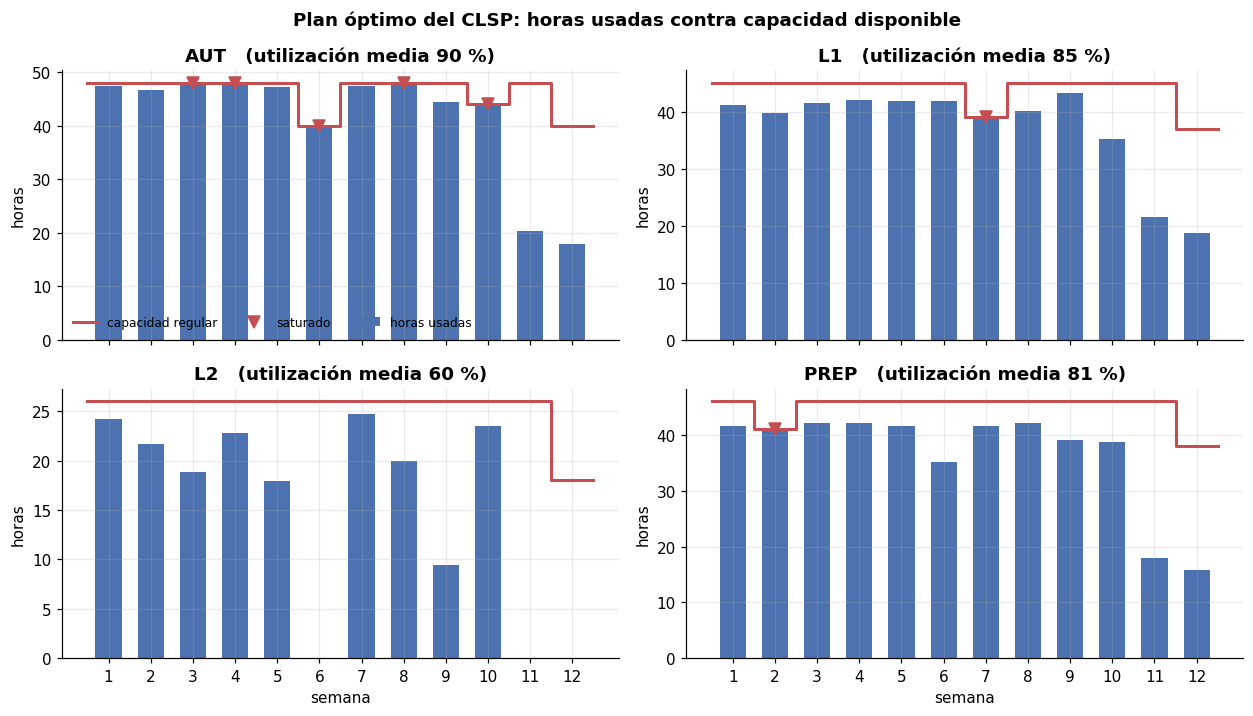

Recurso con mayor utilizacion media en el plan: AUT
Pares (recurso, semana) saturados al 100 %: 7
  AUT/t3, AUT/t4, AUT/t6, AUT/t8, AUT/t10, L1/t7, PREP/t2


In [8]:
uso = {}
for r in REC:
    for t in T:
        uso[(r, t)] = sum(consumo.get((i, r), 0.0) * v["x"][i, t].X
                          + tiempo_setup.get((i, r), 0.0) * round(v["y"][i, t].X)
                          for i in SKUS)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.6), sharex=True)
for ax, r in zip(axes.ravel(), REC):
    horas = [capacidad[(r, t)] for t in T]
    usado = [uso[(r, t)] for t in T]
    sat = [t for k, t in enumerate(T) if usado[k] >= horas[k] - 1e-6]
    ax.bar(T, usado, color="#4c72b0", width=0.62, label="horas usadas")
    ax.step([t - 0.5 for t in T] + [T[-1] + 0.5], horas + [horas[-1]],
            where="post", color="#c44e52", lw=2.0, label="capacidad regular")
    if sat:
        ax.plot(sat, [uso[(r, t)] for t in sat], ls="none", marker="v",
                color="#c44e52", ms=8, zorder=5, label="saturado")
    ax.set_title(f"{r}   (utilización media {100*np.mean(usado)/np.mean(horas):.0f} %)")
    ax.set_ylabel("horas")
axes[0, 0].legend(loc="lower left", fontsize=8, ncol=3)
for ax in axes[1]:
    ax.set_xlabel("semana")
    ax.set_xticks(T)
fig.suptitle("Plan óptimo del CLSP: horas usadas contra capacidad disponible",
             fontweight="bold")
figura(fig, "clsp_utilizacion")
plt.show()

cuello = max(REC, key=lambda r: sum(uso[(r, t)] for t in T) /
             sum(capacidad[(r, t)] for t in T))
saturadas = [(r, t) for r in REC for t in T
             if uso[(r, t)] >= capacidad[(r, t)] - 1e-6]
print(f"Recurso con mayor utilizacion media en el plan: {cuello}")
print(f"Pares (recurso, semana) saturados al 100 %: {len(saturadas)}")
print("  " + ", ".join(f"{r}/t{t}" for r, t in saturadas))

## 8. La semana focal

La semana 3 es la que explica el plan. Vale la pena mirarla sola: cuánta
demanda tiene, cuánto se produce en ella y cuánto llegó adelantado desde las
semanas 1 y 2.

In [9]:
filas = []
for i in SKUS:
    filas.append({"sku": i, "demanda_t3": demanda[(i, 3)],
                  "produccion_t3": v["x"][i, 3].X,
                  "inv_entrada_t3": v["I"][i, 2].X,
                  "setup_t3": int(round(v["y"][i, 3].X))})
foco = pd.DataFrame(filas)
foco["cubierto_adelantando_%"] = 100 * foco.inv_entrada_t3 / foco.demanda_t3
print("Semana 3 (Fiestas Patrias):\n")
print(foco.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

for r in REC:
    nec = sum(consumo.get((i, r), 0.0) * demanda[(i, 3)] for i in SKUS)
    nec += sum(tiempo_setup.get((i, r), 0.0) for i in SKUS)
    disp = capacidad[(r, 3)]
    marca = "  <-- NO CABE" if nec > disp else ""
    print(f"  {r:5s}: producir la demanda de t=3 en t=3 pide {nec:6.1f} h "
          f"y hay {disp:5.1f} h{marca}")
print("\nEse deficit es exactamente lo que el plan adelanta a las semanas 1 y 2,")
print("y es la razon por la que la propiedad de Wagner-Whitin no sobrevive.")

Semana 3 (Fiestas Patrias):

     sku  demanda_t3  produccion_t3  inv_entrada_t3  setup_t3  cubierto_adelantando_%
 DUR-480     1,667.0        1,667.0             0.0         1                     0.0
 DUR-820       357.0        1,528.0             0.0         1                     0.0
 TOM-480     4,341.0        4,527.8            24.9         1                     0.6
TOM-3000       496.0            0.0           496.0         0                   100.0
 POR-480     1,451.0            0.0         1,451.0         0                   100.0
POR-3000       153.0            0.0           153.0         0                   100.0
  AUT  : producir la demanda de t=3 en t=3 pide   56.2 h y hay  48.0 h  <-- NO CABE
  L1   : producir la demanda de t=3 en t=3 pide   50.6 h y hay  45.0 h  <-- NO CABE
  L2   : producir la demanda de t=3 en t=3 pide   22.9 h y hay  26.0 h
  PREP : producir la demanda de t=3 en t=3 pide   49.3 h y hay  46.0 h  <-- NO CABE

Ese deficit es exactamente lo que el plan ade

## 9. Comprobación

In [10]:
print("Comprobación:")
ok = []
ok.append(verificar(m.ObjVal, 16_457_114.0, "objetivo del CLSP básico (CLP)", tol=1e-5))
ok.append(verificar(n_setups, 34, "número de preparaciones", tol=1e-9))
ok.append(verificar(float(bm.loc[1, "gap_raiz_%"]), 54.2,
                    "gap LP en la raíz, big-M ajustado (%)", tol=1e-2))
ok.append(verificar(float(bm.loc[0, "gap_raiz_%"]), 99.2,
                    "gap LP en la raíz, big-M genérico (%)", tol=1e-2))
ok.append(verificar(len(vio), 7, "violaciones de la propiedad de Wagner-Whitin",
                    tol=1e-9))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

# factibilidad recalculada desde los datos, sin preguntarle al solver
peor = max(uso[(r, t)] - capacidad[(r, t)] for r in REC for t in T)
assert peor <= 1e-6, f"el plan viola la capacidad por {peor:.6f} h"
for i in SKUS:
    prev = inv_ini[i]
    for t in T:
        prev = prev + v["x"][i, t].X - demanda[(i, t)]
        assert abs(prev - v["I"][i, t].X) < 1e-6, f"balance roto en {i},{t}"
assert (abs(bm.z_entero - bm.z_entero.iloc[0]) < 1e-3).all(), \
    "las tres versiones del big-M deben dar el MISMO optimo entero"
assert bm.loc[0, "gap_raiz_%"] > bm.loc[1, "gap_raiz_%"] > bm.loc[2, "gap_raiz_%"], \
    "cotas mas ajustadas deben dar gaps mas chicos"
assert cuello == "AUT", "el cuello de botella deberia ser el autoclave"
print("Factibilidad recalculada desde los CSV: capacidad y balance, correctos.")

plan = pd.DataFrame([{"sku": i, "t": t, "demanda": demanda[(i, t)],
                      "produccion": v["x"][i, t].X, "inventario": v["I"][i, t].X,
                      "setup": int(round(v["y"][i, t].X))}
                     for i in SKUS for t in T])
tabla(plan, "clsp_plan")
tabla(util, "clsp_utilizacion_demanda")
tabla(bm, "clsp_bigM")
resumen({"objetivo_clsp": float(m.ObjVal), "n_setups": n_setups,
         "gap_raiz_generico_pct": float(bm.loc[0, "gap_raiz_%"]),
         "gap_raiz_ajustado_pct": float(bm.loc[1, "gap_raiz_%"]),
         "gap_raiz_a_medida_pct": float(bm.loc[2, "gap_raiz_%"]),
         "costo_variable_excluido": float(costo_variable),
         "cuello_de_botella": cuello,
         "n_violaciones_WW": int(len(vio))}, "resumen_clsp")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] objetivo del CLSP básico (CLP): obtenido 16,457,113.8652 | referencia 16,457,114.0000 | dif. relativa 8.19e-09
  [  OK  ] número de preparaciones: obtenido 34.0000 | referencia 34.0000 | dif. relativa 0.00e+00
  [  OK  ] gap LP en la raíz, big-M ajustado (%): obtenido 54.2470 | referencia 54.2000 | dif. relativa 8.66e-04
  [  OK  ] gap LP en la raíz, big-M genérico (%): obtenido 99.1694 | referencia 99.2000 | dif. relativa 3.08e-04
  [  OK  ] violaciones de la propiedad de Wagner-Whitin: obtenido 7.0000 | referencia 7.0000 | dif. relativa 0.00e+00

5/5 comprobaciones correctas
Factibilidad recalculada desde los CSV: capacidad y balance, correctos.
Guardado en resultados/


---

## Para llevarse

1. **La capacidad no agrega una restricción: cambia el problema.** Se cae la
   propiedad de Wagner-Whitin —hay 7 pares (i, t) que la violan en el óptimo—
   y con ella se cae la programación dinámica. El CLSP es NP-difícil.
2. **El big-M con capacidad tiene dos cotas, no una.** La económica (demanda
   restante) y la física (lo que cabe en el recurso más restrictivo de esa
   semana). Usar el mínimo baja el gap en la raíz de 99 % a 54 %, con el mismo
   óptimo entero; ajustarlo a medida de este modelo lo baja a 45 %.
3. **Una cota reutilizable es una cota más floja.** Si la misma función debe
   servir para variantes con horas extra y con reservas, hay que aflojarla, y
   eso se paga en gap. Es una decisión legítima, pero hay que tomarla a
   conciencia y documentarla, no heredarla.
4. **El setup consume horas, no solo dinero.** Si el tiempo de setup no entra
   en la restricción de capacidad, el plan que sale no cabe en la planta.
5. **Identificar el cuello de botella es trabajo previo a optimizar.** AUT
   está al 92 % de sus horas regulares en el horizonte completo. Todo lo que
   decide este modelo es, en el fondo, un reparto de horas de autoclave.
6. **El costo variable de producción no se optimiza: se reporta.** Es el 98 %
   del gasto y es casi constante. Meterlo en el objetivo hace que cualquier
   mejora de planificación se vea como ruido decimal.

## Ejercicios

1. Elimine la restricción de capacidad de AUT y vuelva a resolver. ¿Cuánto
   baja el objetivo? Esa diferencia es el valor de las horas de autoclave; con
   ella discuta si conviene la inversión en un segundo autoclave.
2. Resuelva dejando el tiempo de setup **fuera** de la restricción de
   capacidad. El objetivo baja. Verifique con el cálculo de horas de la
   sección 7 que el plan resultante no cabe: es un plan más barato y falso.
3. Suba la demanda de la semana 3 en pasos de 10 % y resuelva. ¿En qué punto
   el modelo se vuelve infactible? Antes de correrlo, prediga qué recurso será
   el culpable y compruébelo con `m.computeIIS()`.
4. La función `big_M` tiene el interruptor `con_backlog`, que aquí nunca se
   usa. Lea la rama y explique, **antes** de abrir el cuaderno 03, por qué la
   cota económica deja de ser válida cuando se permite diferir demanda.
5. Cuente cuántos pares (recurso, semana) quedan saturados al 100 % en el
   plan óptimo. ¿Son los mismos que la tabla de la sección 2 anticipaba? Si no
   lo son, explique qué hizo el modelo para descomprimirlos.